# S08 - Démonstration 2: Telco
Classification avec [les données de désabonnement du service client](https://www.kaggle.com/blastchar/telco-customer-churn).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, precision_score,
                             recall_score)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV)
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Bloc 1: chargement des données

In [2]:
# Chargement des données
url = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/data/Telco-Customer-Churn_dummies.csv'
customer_data = pd.read_csv(url)
customer_data.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,1,...,0,0,0,0,0,1,0,1,0,1


## Bloc 2: extraction des caractéristiques
Voir le fichier complément pour le détail de l'extraction des caractéristiques.

In [3]:
# Prendre toutes les colonnes sauf la dernière
# La dernière colonne est la valeur cible
selected_features = customer_data.columns[:-1].values
X = customer_data[selected_features].values
y = customer_data['Churn_Yes'].values
print(f"X: {X[:5]}")
print(f"y: {y[:5]}")

X: [[0.00000e+00 1.00000e+00 2.98500e+01 2.98500e+01 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00]
 [0.00000e+00 3.40000e+01 5.69500e+01 1.88950e+03 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
 [0.00000e+00 2.00000e+00 5.38500e+01 1.08150e+02 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
 [0.00000e+00 4.50000e+01 4.23000e+01 1.84075e+03 1.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.0000

## Bloc 3: modèles et entraînement

In [4]:
# Séparation des données pour l'entraînement et l'évaluation (75%/25% par défaut)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
print(f"Nombre d'observations pour l'entraînement: {X_train.shape[0]}")
print(f"Nombre d'observations pour l'évaluation: {X_test.shape[0]}")

Nombre d'observations pour l'entraînement: 5274
Nombre d'observations pour l'évaluation: 1758


### Modèle de régression logistique

In [5]:
# Entraînement de la régression logistique
# avec une recherche d'hyperparamètre avec une grille (grid search)
# et une validation croisée
best_score = 0
for C in [0.001, 0.01, 1, 10, 100, 1000]:
    # on crée le modèle
    logreg = LogisticRegression(max_iter=10000, random_state=0, C=C)
    # on fait la validation croisée
    scores = cross_val_score(logreg, X_train, y_train, cv=5)
    # on calcule la justesse moyenne
    score = np.mean(scores)
    #print(scores, score)
    # si le score est meilleur, on le conserve (avec le paramètre C)
    if score > best_score:
        best_score = score
        best_C = C
# réentraîner le meilleur modèle sur toutes les données d'entraînement
logreg = LogisticRegression(max_iter=10000, random_state=0, C=best_C)
logreg.fit(X_train, y_train)  

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicla

### Modèle d'arbre de décision

In [6]:
# Entraînement de l'arbre de décision
# Ce code est similaire au précédent, mais il utilise la fonction GridSearchCV
# Voir la section 5.2.3 du livre "Intro to ML with Python" pour plus d'information
param_grid = {'max_leaf_nodes': [10, 20, 28, 30, 40],
              'random_state': [0]}
tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5,
                    return_train_score=True)
tree.fit(X_train, y_train)  # ceci retourne automatiquement le meilleur estimateur entraîné sur toutes les données train

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': [10, 20, ...], 'random_state': [0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fol

In [7]:
# Analyse des résultats de la validation croisée
cv_results = pd.DataFrame(tree.cv_results_)
display(cv_results)
print(tree.best_estimator_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_leaf_nodes,param_random_state,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.003686,0.000161,0.000238,0.000038,10,0,"{'max_leaf_nodes': 10, 'random_state': 0}",0.790521,0.777251,0.781043,...,0.782708,0.004412,5,0.785731,0.796871,0.791183,0.789050,0.795024,0.791572,0.004016
1,0.004278,0.000102,0.000195,0.000026,20,0,"{'max_leaf_nodes': 20, 'random_state': 0}",0.789573,0.779147,0.787678,...,0.785171,0.006010,4,0.806826,0.801375,0.800901,0.803745,0.800237,0.802617,0.002414
2,0.004530,0.000063,0.000188,0.000022,28,0,"{'max_leaf_nodes': 28, 'random_state': 0}",0.798104,0.794313,0.786730,...,0.790669,0.006968,2,0.814648,0.813463,0.812515,0.808959,0.802607,0.810438,0.004352
3,0.004573,0.000087,0.000186,0.000030,30,0,"{'max_leaf_nodes': 30, 'random_state': 0}",0.800948,0.794313,0.785782,...,0.793135,0.005199,1,0.816070,0.813463,0.814648,0.811567,0.807346,0.812619,0.003022
4,0.004745,0.000116,0.000187,0.000026,40,0,"{'max_leaf_nodes': 40, 'random_state': 0}",0.798104,0.787678,0.786730,...,0.790481,0.004309,3,0.821759,0.819626,0.819626,0.815596,0.819905,0.819302,0.002017


DecisionTreeClassifier(max_leaf_nodes=30, random_state=0)


## Évaluation
Calcul de la précision et du rappel du modèle récemment ajusté (régression logistique ou arbre de décision)

In [8]:
# Affichage des résultats
y_predict = logreg.predict(X_test) # à utiliser pour la régression logistique
print("**Régression logistique**")
print(f"Justesse (entraînement): {logreg.score(X_train, y_train):.3f}")  # accuracy
print(f"Justesse (test): {logreg.score(X_test, y_test):.3f}")  # accuracy
print(f"Précision (test): {precision_score(y_test, y_predict):.3f}")
print(f"Rappel (test): {recall_score(y_test, y_predict):.3f}")
print(f"Matrice de confusion (test):\n{confusion_matrix(y_test, y_predict)}")

y_predict = tree.predict(X_test)
print("\n**Arbre de décision**")
print(f"Justesse (entraînement): {tree.score(X_train, y_train):.3f}")  # accuracy
print(f"Justesse (test): {tree.score(X_test, y_test):.3f}")  # accuracy
print(f"Précision (test): {precision_score(y_test, y_predict):.3f}")
print(f"Rappel (test): {recall_score(y_test, y_predict):.3f}")
print(f"Matrice de confusion (test):\n{confusion_matrix(y_test, y_predict)}")

**Régression logistique**
Justesse (entraînement): 0.805
Justesse (test): 0.812
Précision (test): 0.653
Rappel (test): 0.553
Matrice de confusion (test):
[[1180  131]
 [ 200  247]]

**Arbre de décision**
Justesse (entraînement): 0.811
Justesse (test): 0.796
Précision (test): 0.641
Rappel (test): 0.452
Matrice de confusion (test):
[[1198  113]
 [ 245  202]]


Voici le code pour tracer [la courbe de précision-rappel ](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#sphx-glr-auto-examples-model-selection-plot-precision-recall-py).

*La courbe précision-rappel est généralement utilisée pour analyser un modèle de régression logistique pour toutes les valeurs de seuils possibles, mais vous trouverez également le code pour l'arbre de décision dans la prochaine cellule*

Text(0.5, 1.0, 'Précision moyenne=0.64')

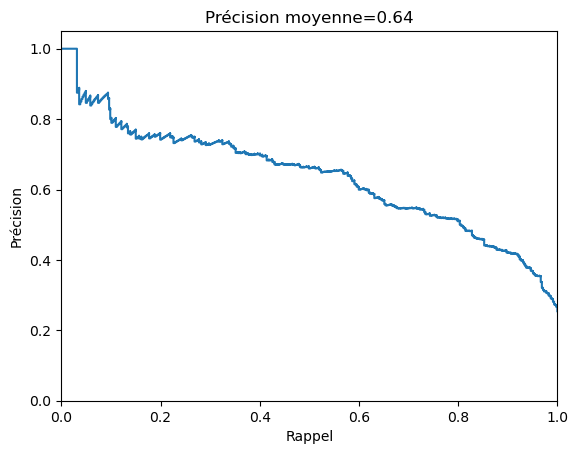

In [9]:
# Régression logistique
y_prob = logreg.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.step(recall, precision)
average_precision = average_precision_score(y_test, y_prob)

plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Précision moyenne={average_precision:0.2f}')

Text(0.5, 1.0, 'Précision moyenne=0.59')

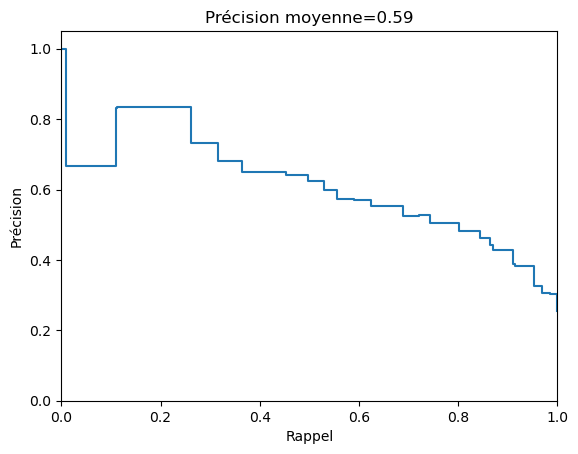

In [10]:
# Arbre de décision
y_prob = tree.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.step(recall, precision)
average_precision = average_precision_score(y_test, y_prob)

plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Précision moyenne={average_precision:0.2f}')